# Banking Credit Risk Analytics

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset

df = pd.read_csv('../data/raw_data.csv')

In [3]:
# Check dataset dimensions

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 32581
Columns : 12


In [4]:
# Display first 5 rows

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
# Rename columns for better readability

df = df.rename(columns={
    'person_age': 'Age',
    'person_income': 'Income',
    'person_home_ownership': 'Home_Ownership',
    'person_emp_length': 'Employment_Years',
    'loan_intent': 'Loan_Purpose',
    'loan_grade': 'Loan_Grade',
    'loan_amnt': 'Loan_Amount',
    'loan_int_rate': 'Interest_Rate',
    'loan_status': 'Loan_Status',
    'loan_percent_income': 'Loan_to_Income_Ratio',
    'cb_person_default_on_file': 'Previous_Default',
    'cb_person_cred_hist_length': 'Credit_History_Years'
})

In [6]:
# Display updated column names

df.columns

Index(['Age', 'Income', 'Home_Ownership', 'Employment_Years', 'Loan_Purpose',
       'Loan_Grade', 'Loan_Amount', 'Interest_Rate', 'Loan_Status',
       'Loan_to_Income_Ratio', 'Previous_Default', 'Credit_History_Years'],
      dtype='object')

## Data Overview

In [7]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   32581 non-null  int64  
 1   Income                32581 non-null  int64  
 2   Home_Ownership        32581 non-null  object 
 3   Employment_Years      31686 non-null  float64
 4   Loan_Purpose          32581 non-null  object 
 5   Loan_Grade            32581 non-null  object 
 6   Loan_Amount           32581 non-null  int64  
 7   Interest_Rate         29465 non-null  float64
 8   Loan_Status           32581 non-null  int64  
 9   Loan_to_Income_Ratio  32581 non-null  float64
 10  Previous_Default      32581 non-null  object 
 11  Credit_History_Years  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
# Missing values count

df.isnull().sum()

Age                        0
Income                     0
Home_Ownership             0
Employment_Years         895
Loan_Purpose               0
Loan_Grade                 0
Loan_Amount                0
Interest_Rate           3116
Loan_Status                0
Loan_to_Income_Ratio       0
Previous_Default           0
Credit_History_Years       0
dtype: int64

### Duplicate Record Analysis

In [9]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records : {duplicate_count}")

Duplicate Records : 165


### Data Validation

In [10]:
# Validate key numerical columns to identify suspicious values

print(f"Minimum Age : {df['Age'].min()}")
print(f"Maximum Age : {df['Age'].max()}")

print(f"\nMinimum Employment Years : {df['Employment_Years'].min()}")
print(f"Maximum Employment Years : {df['Employment_Years'].max()}")

print(f"\nMinimum Interest Rate : {df['Interest_Rate'].min()}")
print(f"Maximum Interest Rate : {df['Interest_Rate'].max()}")

Minimum Age : 20
Maximum Age : 144

Minimum Employment Years : 0.0
Maximum Employment Years : 123.0

Minimum Interest Rate : 5.42
Maximum Interest Rate : 23.22


## Data Cleaning

In [11]:
# Remove duplicate records

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records Before Cleaning : {duplicate_count}")

df = df.drop_duplicates()

print(f"Rows After Removing Duplicates : {df.shape[0]}")

Duplicate Records Before Cleaning : 165
Rows After Removing Duplicates : 32416


In [12]:
# Remove invalid age records

invalid_age = df[df['Age'] > 100].shape[0]

print(f"Invalid Age Records : {invalid_age}")

df = df[df['Age'] <= 100]

print(f"Rows After Removing Invalid Ages : {df.shape[0]}")

Invalid Age Records : 5
Rows After Removing Invalid Ages : 32411


In [13]:
# Fill missing employment years using median

employment_median = df['Employment_Years'].median()

print(f"Median Employment Years : {employment_median}")

df['Employment_Years'] = df['Employment_Years'].fillna(employment_median)

print(f"Remaining Missing Values : {df['Employment_Years'].isnull().sum()}")

Median Employment Years : 4.0
Remaining Missing Values : 0


In [14]:
# Remove invalid employment records

invalid_emp = df[df['Employment_Years'] > df['Age']].shape[0]

print(f"Invalid Employment Records : {invalid_emp}")

df = df[df['Employment_Years'] <= df['Age']]

print(f"Rows After Removing Invalid Employment Records : {df.shape[0]}")

Invalid Employment Records : 2
Rows After Removing Invalid Employment Records : 32409


In [15]:
# Fill missing interest rates using loan grade median

df['Interest_Rate'] = (
    df.groupby('Loan_Grade')['Interest_Rate']
      .transform(lambda x: x.fillna(x.median()))
)

print(f"Remaining Missing Values : {df['Interest_Rate'].isnull().sum()}")

Remaining Missing Values : 0


In [16]:
# Final validation after cleaning

print("Dataset Shape :", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nMaximum Age :", df['Age'].max())
print("Maximum Employment Years :", df['Employment_Years'].max())
print("Maximum Interest Rate :", df['Interest_Rate'].max())

Dataset Shape : (32409, 12)

Missing Values:
Age                     0
Income                  0
Home_Ownership          0
Employment_Years        0
Loan_Purpose            0
Loan_Grade              0
Loan_Amount             0
Interest_Rate           0
Loan_Status             0
Loan_to_Income_Ratio    0
Previous_Default        0
Credit_History_Years    0
dtype: int64

Duplicate Records:
0

Maximum Age : 94
Maximum Employment Years : 41.0
Maximum Interest Rate : 23.22


In [17]:
# Export cleaned dataset

df.to_csv('../data/cleaned_data.csv', index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


## Feature Engineering

In [18]:
# Create customer age categories

df['Age_Category'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 100],
    labels=[
        'Young',
        'Adult',
        'Mid-Career',
        'Experienced',
        'Senior'
    ]
)

In [19]:
df['Age_Category'].value_counts()

Age_Category
Young          15243
Adult          13711
Mid-Career      2809
Experienced      512
Senior           134
Name: count, dtype: int64

In [20]:
# Create income categories

df['Income_Category'] = pd.cut(
    df['Income'],
    bins=[0, 40000, 80000, 150000, float('inf')],
    labels=[
        'Low Income',
        'Middle Income',
        'High Income',
        'Very High Income'
    ]
)

In [21]:
df['Income_Category'].value_counts()

Income_Category
Middle Income       15575
Low Income           9223
High Income          6483
Very High Income     1128
Name: count, dtype: int64

In [22]:
# Create employment categories

df['Employment_Category'] = pd.cut(
    df['Employment_Years'],
    bins=[-1, 2, 5, 10, float('inf')],
    labels=[
        'New Employee',
        'Early Career',
        'Mid Career',
        'Experienced'
    ]
)

In [23]:
df['Employment_Category'].value_counts()

Employment_Category
New Employee    10814
Early Career    10116
Mid Career       8564
Experienced      2915
Name: count, dtype: int64

In [24]:
df['Credit_History_Years'].describe()

count    32409.000000
mean         5.811194
std          4.057899
min          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         30.000000
Name: Credit_History_Years, dtype: float64

In [25]:
df['Credit_History_Years'].quantile([0.25,0.50,0.75,0.90])

0.25     3.0
0.50     4.0
0.75     8.0
0.90    11.0
Name: Credit_History_Years, dtype: float64

In [26]:
# Create credit history categories

df['Credit_History_Category'] = pd.cut(
    df['Credit_History_Years'],
    bins=[1, 3, 7, 11, float('inf')],
    labels=[
        'New Credit User',
        'Moderate Credit History',
        'Established Credit',
        'Long Credit History'
    ]
)

In [27]:
df['Credit_History_Category'].value_counts()

Credit_History_Category
New Credit User            11826
Moderate Credit History    11501
Established Credit          6089
Long Credit History         2993
Name: count, dtype: int64

In [28]:
# Create loan size categories

df['Loan_Size_Category'] = pd.cut(
    df['Loan_Amount'],
    bins=[0, 5000, 10000, 20000, float('inf')],
    labels=[
        'Small Loan',
        'Medium Loan',
        'Large Loan',
        'Very Large Loan'
    ]
)

In [29]:
df['Loan_Size_Category'].value_counts()

Loan_Size_Category
Medium Loan        11982
Small Loan          9428
Large Loan          8872
Very Large Loan     2127
Name: count, dtype: int64

In [30]:
# Create debt burden categories

df['Debt_Burden'] = pd.cut(
    df['Loan_to_Income_Ratio'],
    bins=[0, 0.10, 0.20, 0.30, float('inf')],
    labels=[
        'Low Burden',
        'Moderate Burden',
        'High Burden',
        'Very High Burden'
    ]
)

In [31]:
df['Debt_Burden'].value_counts()

Debt_Burden
Moderate Burden     11999
Low Burden          10418
High Burden          6166
Very High Burden     3818
Name: count, dtype: int64

In [32]:
# Create interest rate categories

df['Interest_Rate_Category'] = pd.cut(
    df['Interest_Rate'],
    bins=[0, 8, 11, 15, float('inf')],
    labels=[
        'Low Interest',
        'Moderate Interest',
        'High Interest',
        'Very High Interest'
    ]
)

In [33]:
df['Interest_Rate_Category'].value_counts()

Interest_Rate_Category
High Interest         11689
Low Interest           8895
Moderate Interest      7967
Very High Interest     3858
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

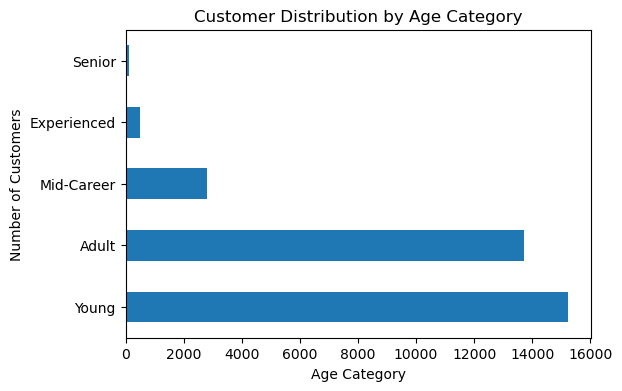

In [34]:
# Customer Distribution by Age Category

plt.figure(figsize=(6,4))

df['Age_Category'].value_counts().plot(kind='barh')

plt.title('Customer Distribution by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Number of Customers')

plt.show()

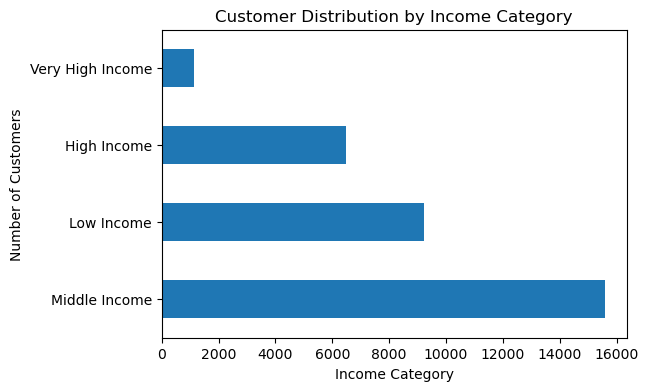

In [35]:
# Customer Distribution by Income Category

plt.figure(figsize=(6,4))

df['Income_Category'].value_counts().plot(kind='barh')

plt.title('Customer Distribution by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Number of Customers')

plt.show()

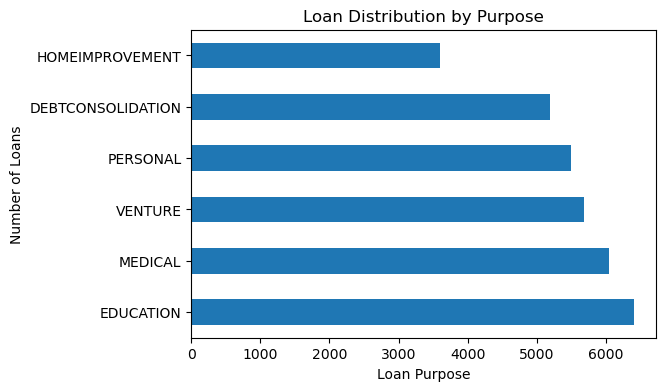

In [36]:
# Loan Distribution by Loan Purpose

plt.figure(figsize=(6,4))

df['Loan_Purpose'].value_counts().plot(kind='barh')

plt.title('Loan Distribution by Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Loans')

plt.show()

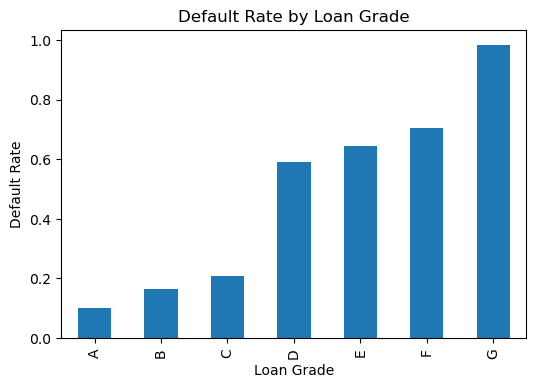

In [37]:
# Default Rate by Loan Grade

(
    df.groupby('Loan_Grade')['Loan_Status']
    .mean()
    .plot(kind='bar', figsize=(6,4))
)

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')

plt.show()

C:\Users\prjos\AppData\Local\Temp\ipykernel_1900\1120154276.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Debt_Burden')['Loan_Status']


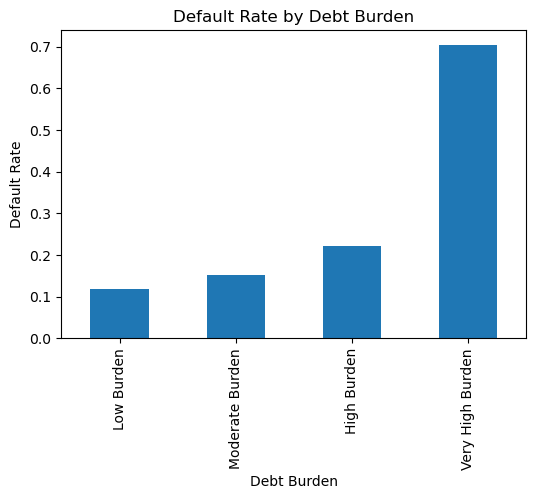

In [38]:
# Default Rate by Debt Burden

(
    df.groupby('Debt_Burden')['Loan_Status']
    .mean()
    .plot(kind='bar', figsize=(6,4))
)

plt.title('Default Rate by Debt Burden')
plt.xlabel('Debt Burden')
plt.ylabel('Default Rate')

plt.show()

In [39]:
# Export final dataset

df.to_csv('../data/final_data.csv', index=False)

print('Final dataset exported successfully.')

Final dataset exported successfully.
